# Finite-difference approximations of the derivative

We approximate $f'(x)$ for $f(x) = \sin(x)$ at $x = 1$ using two finite-difference formulas:

- **First-order (forward difference):**
$$f'(x) \approx \frac{f_{i+1} - f_i}{h} = \frac{f(x+h) - f(x)}{h} $$

- **Second-order (central difference):**
$$f'(x) \approx \frac{f_{i+1} - f_{i-1}}{2h} = \frac{f(x+h) - f(x-h)}{h} $$

The C++ program (`src/main.cpp`) sweeps $h$ over a logarithmic range ($10^{-1}$ down to $10^{-12}$), computes both approximations, and stores the absolute error against the exact derivative $\cos(x)$ in an HDF5 file (`build/results.h5`).

A Taylor expansion predicts the error should scale as:

- $\text{error}_1(h) = O(h)$ for the first-order scheme,
- $\text{error}_2(h) = O(h^2)$ for the second-order scheme,

which means on a log-log plot of error vs. $h$, the first-order curve should have a slope of about 1, and the second-order curve a slope of about 2, until round-off error dominates at very small $h$.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with h5py.File("build/results.h5", "r") as f:
    h = f["h"][:]
    error_1 = f["error_first_order"][:]
    error_2 = f["error_second_order"][:]
    x = f.attrs["x"]
    exact_derivative = f.attrs["exact_derivative"]

print(f"x = {x}, exact derivative f'(x) = {exact_derivative}")
print(f"{len(h)} values of h, ranging from {h.min():.2e} to {h.max():.2e}")

x = 1.0, exact derivative f'(x) = 0.5403023058681398
56 values of h, ranging from 1.00e-12 to 1.00e-01


## Log-log plot of the error vs. $h$

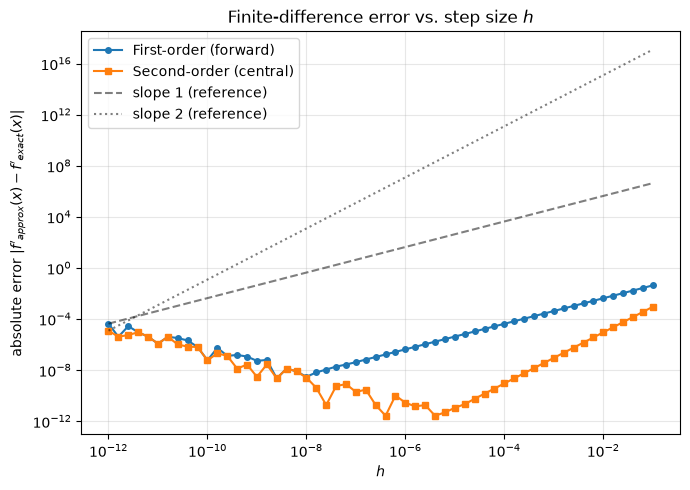

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(h, error_1, "o-", label="First-order (forward)", markersize=4)
ax.loglog(h, error_2, "s-", label="Second-order (central)", markersize=4)

# Reference slopes for comparison
h_ref = np.array([h.min(), h.max()])
ax.loglog(h_ref, error_1[-1] * (h_ref / h[-1]) ** 1, "k--", alpha=0.5, label="slope 1 (reference)")
ax.loglog(h_ref, error_2[-1] * (h_ref / h[-1]) ** 2, "k:", alpha=0.5, label="slope 2 (reference)")

ax.set_xlabel("$h$")
ax.set_ylabel("absolute error $|f'_{approx}(x) - f'_{exact}(x)|$")
ax.set_title("Finite-difference error vs. step size $h$")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## Estimating the observed order of convergence

The order of convergence can be estimated as the local slope of $\log(\text{error})$ vs. $\log(h)$:

$$p \approx \frac{\log(\text{error}(h_i)) - \log(\text{error}(h_{i+1}))}{\log(h_i) - \log(h_{i+1})}$$

In [4]:
log_h = np.log10(h)
log_e1 = np.log10(error_1)
log_e2 = np.log10(error_2)

order_1 = np.diff(log_e1) / np.diff(log_h)
order_2 = np.diff(log_e2) / np.diff(log_h)

# Clean (pre-round-off) regions differ between schemes: central difference
# hits its round-off floor at a much larger h than forward difference
mask_1 = h[:-1] > 1e-7
mask_2 = h[:-1] > 1e-4

print(f"Average observed order (first-order scheme):  {order_1[mask_1].mean():.3f}")
print(f"Average observed order (second-order scheme): {order_2[mask_2].mean():.3f}")

Average observed order (first-order scheme):  1.002
Average observed order (second-order scheme): 2.000


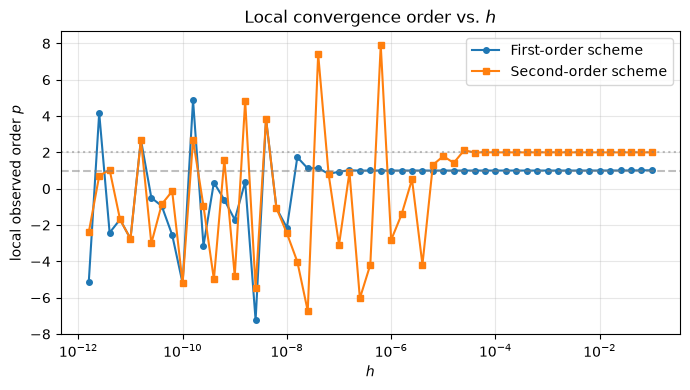

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

h_mid = h[:-1]
ax.semilogx(h_mid, order_1, "o-", label="First-order scheme", markersize=4)
ax.semilogx(h_mid, order_2, "s-", label="Second-order scheme", markersize=4)
ax.axhline(1, color="gray", linestyle="--", alpha=0.5)
ax.axhline(2, color="gray", linestyle=":", alpha=0.5)

ax.set_xlabel("$h$")
ax.set_ylabel("local observed order $p$")
ax.set_title("Local convergence order vs. $h$")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Conclusion

- In their respective clean (pre-round-off) regions, the forward-difference error decreases with slope $\approx 1$ and the central-difference error decreases with slope $\approx 2$, confirming that the two schemes are first-order and second-order accurate, respectively.
- Both curves plateau and become noisy as floating-point round-off dominates the truncation error. This happens at a much larger $h$ for the central-difference scheme ($h \approx 10^{-5}$) than for the forward-difference scheme ($h \approx 10^{-8}$).
- This sets a practical lower bound on how small $h$ can usefully be, depending on the order of the approximation.